### =========================================================
## **INTERACTIVE MOBILE SALES DASHBOARD USING MATPLOTLIB**
### ========================================================

##### Import Libraries

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

##### load the Data set

In [8]:
df = pd.read_excel('Mobile Sales Data.xlsx')

In [9]:
df.sample(5)

,Transaction ID,Day,Month,Year,Day Name,Brand,Units Sold,Price Per Unit,Customer Name,Customer Age,City,Payment Method,Customer Ratings,Mobile Model
482,483,21,2,2022,Monday,OnePlus,1,23462.15,Ramesh Gupta,28,Mumbai,Credit Card,5,OnePlus Nord
3305,3306,8,5,2024,Wednesday,Xiaomi,2,12276.30,Sanjay Jain,33,Delhi,Cash,5,Mi 11
759,760,14,5,2022,Saturday,Samsung,2,40017.87,Meena Mathur,51,Mumbai,Debit Card,3,Galaxy S21
3502,3503,2,7,2024,Tuesday,Vivo,3,44437.03,Monika Mehta,23,Hyderabad,Debit Card,5,Vivo Y51
2807,2808,15,12,2023,Friday,Apple,7,19316.60,Sunita Iyer,21,Delhi,Cash,2,iPhone 11


##### Select total sales column

In [10]:
df['Total Sales'] = df['Units Sold'] * df['Price Per Unit']

In [11]:
df['Total Sales']

0        61048.20
1        63391.14
2       468220.64
3       127819.90
4       144504.06
          ...    
3830    390655.08
3831    277402.48
3832    263341.61
3833     67844.16
3834     50375.07
Name: Total Sales, Length: 3835, dtype: float64

## **INTERACTIVE MOBILE SALES DASHBOARD**


Available Brands :
['Xiaomi' 'Vivo' 'OnePlus' 'Samsung' 'Apple']



Enter Brand Name (or type ALL) :  All



Available Payment Methods :
['UPI' 'Credit Card' 'Cash' 'Debit Card']



Enter Payment Method (or type ALL) :  All


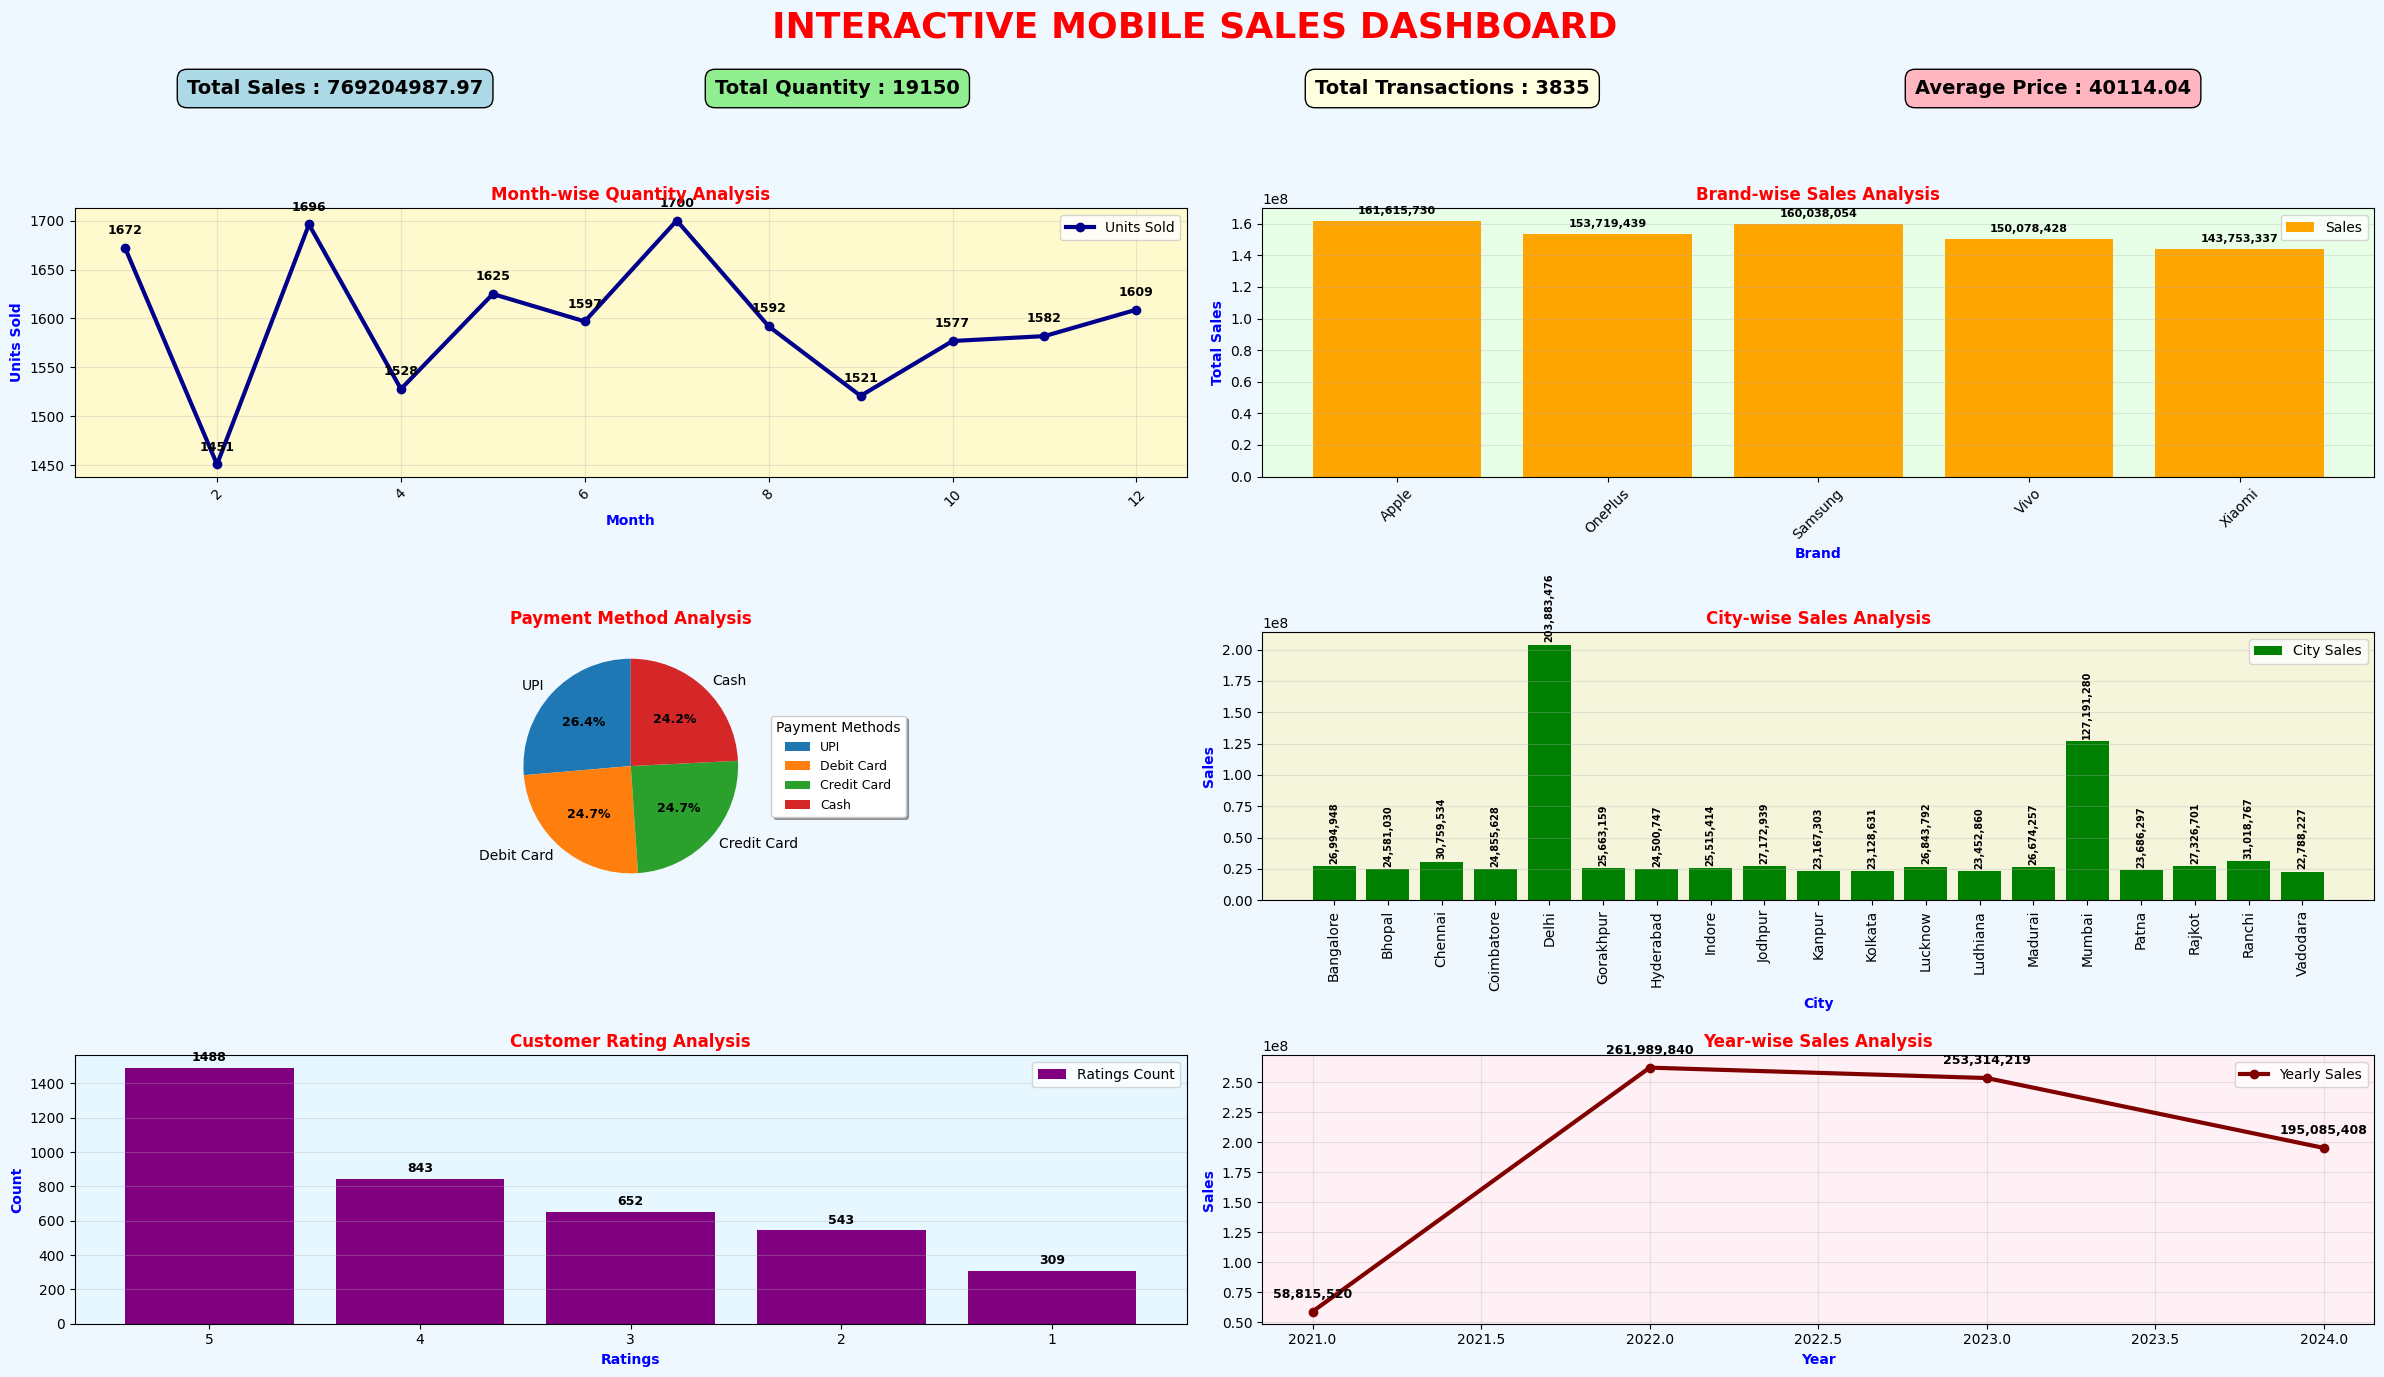

In [30]:
# ---------------------------------------------------------
# Dashboard Filters
# ---------------------------------------------------------

print("\nAvailable Brands :")
print(df['Brand'].unique())

brand_input = input("\nEnter Brand Name (or type ALL) : ")

print("\nAvailable Payment Methods :")
print(df['Payment Method'].unique())

payment_input = input("\nEnter Payment Method (or type ALL) : ")

# ---------------------------------------------------------
# Apply Filters
# ---------------------------------------------------------

filtered_df = df.copy()

if brand_input.upper() != 'ALL':
    filtered_df = filtered_df[
        filtered_df['Brand'].str.lower() == brand_input.lower()
    ]

if payment_input.upper() != 'ALL':
    filtered_df = filtered_df[
        filtered_df['Payment Method'].str.lower() == payment_input.lower()
    ]

# ---------------------------------------------------------
# KPI Calculations
# ---------------------------------------------------------

total_sales = filtered_df['Total Sales'].sum()
total_quantity = filtered_df['Units Sold'].sum()
total_transactions = filtered_df['Transaction ID'].nunique()
avg_price = filtered_df['Price Per Unit'].mean()

# =========================================================
# FIGURE
# =========================================================

fig = plt.figure(figsize=(24,14))
fig.patch.set_facecolor('#f0f8ff')

# ---------------------------------------------------------
# Dashboard Title
# ---------------------------------------------------------

fig.suptitle(
    'INTERACTIVE MOBILE SALES DASHBOARD',
    fontsize=26,
    fontweight='bold',
    color='red'
)

# ---------------------------------------------------------
# KPI CARDS
# ---------------------------------------------------------

plt.figtext(
    0.08, 0.92,
    f'Total Sales : {round(total_sales,2)}',
    fontsize=14,
    fontweight='bold',
    bbox=dict(facecolor='lightblue',
              edgecolor='black',
              boxstyle='round,pad=0.5')
)

plt.figtext(
    0.30, 0.92,
    f'Total Quantity : {total_quantity}',
    fontsize=14,
    fontweight='bold',
    bbox=dict(facecolor='lightgreen',
              edgecolor='black',
              boxstyle='round,pad=0.5')
)

plt.figtext(
    0.55, 0.92,
    f'Total Transactions : {total_transactions}',
    fontsize=14,
    fontweight='bold',
    bbox=dict(facecolor='lightyellow',
              edgecolor='black',
              boxstyle='round,pad=0.5')
)

plt.figtext(
    0.80, 0.92,
    f'Average Price : {round(avg_price,2)}',
    fontsize=14,
    fontweight='bold',
    bbox=dict(facecolor='lightpink',
              edgecolor='black',
              boxstyle='round,pad=0.5')
)

# =========================================================
# 1. MONTH-WISE QUANTITY ANALYSIS
# =========================================================

ax1 = plt.subplot(3,2,1)

month_quantity = filtered_df.groupby('Month')['Units Sold'].sum()

ax1.plot(
    month_quantity.index,
    month_quantity.values,
    marker='o',
    linewidth=3,
    color='darkblue',
    label='Units Sold'
)

# Adjusted Data Points
for x, y in zip(month_quantity.index, month_quantity.values):
    ax1.annotate(
        str(y),
        (x, y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

ax1.set_title(
    'Month-wise Quantity Analysis',
    color='red',
    fontweight='bold'
)

ax1.set_xlabel(
    'Month',
    color='blue',
    fontweight='bold'
)

ax1.set_ylabel(
    'Units Sold',
    color='blue',
    fontweight='bold'
)

ax1.tick_params(axis='x', colors='black', rotation=45)
ax1.tick_params(axis='y', colors='black')

ax1.legend()

ax1.grid(alpha=0.3)

ax1.set_facecolor('#fffacd')

# =========================================================
# 2. BRAND-WISE SALES ANALYSIS
# =========================================================

ax2 = plt.subplot(3,2,2)

brand_sales = filtered_df.groupby('Brand')['Total Sales'].sum()

bars = ax2.bar(
    brand_sales.index,
    brand_sales.values,
    color='orange',
    label='Sales'
)

# Adjusted Data Labels
for bar in bars:
    height = bar.get_height()
    ax2.annotate(
        f'{height:,.0f}',
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext=(0,5),
        textcoords='offset points',
        ha='center',
        fontsize=8,
        fontweight='bold',
        rotation=0
    )

ax2.set_title(
    'Brand-wise Sales Analysis',
    color='red',
    fontweight='bold'
)

ax2.set_xlabel(
    'Brand',
    color='blue',
    fontweight='bold'
)

ax2.set_ylabel(
    'Total Sales',
    color='blue',
    fontweight='bold'
)

ax2.tick_params(axis='x', colors='black', rotation=45)
ax2.tick_params(axis='y', colors='black')

ax2.legend()

ax2.grid(axis='y', alpha=0.3)

ax2.set_facecolor('#e6ffe6')

# =========================================================
# 3. PAYMENT METHOD ANALYSIS
# =========================================================

ax3 = plt.subplot(3,2,3)

payment = filtered_df['Payment Method'].value_counts()

wedges, texts, autotexts = ax3.pie(
    payment.values,
    labels=payment.index,
    autopct='%1.1f%%',
    startangle=90
)

for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')

ax3.set_title(
    'Payment Method Analysis',
    color='red',
    fontweight='bold'
)

ax3.legend(
    payment.index,
    title='Payment Methods',
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    fontsize=9,
    title_fontsize=10,
    frameon=True,
    shadow=True
)
ax3.set_facecolor('#ffe6f2')

# =========================================================
# 4. CITY-WISE SALES ANALYSIS
# =========================================================

ax4 = plt.subplot(3,2,4)

city_sales = filtered_df.groupby('City')['Total Sales'].sum()

bars2 = ax4.bar(
    city_sales.index,
    city_sales.values,
    color='green',
    label='City Sales'
)

# Adjusted Data Labels
for bar in bars2:
    height = bar.get_height()
    ax4.annotate(
        f'{height:,.0f}',
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext=(0,3),
        textcoords='offset points',
        ha='center',
        fontsize=7,
        rotation=90,
        fontweight='bold'
    )

ax4.set_title(
    'City-wise Sales Analysis',
    color='red',
    fontweight='bold'
)

ax4.set_xlabel(
    'City',
    color='blue',
    fontweight='bold'
)

ax4.set_ylabel(
    'Sales',
    color='blue',
    fontweight='bold'
)

ax4.tick_params(axis='x', colors='black', rotation=90)
ax4.tick_params(axis='y', colors='black')

ax4.legend()

ax4.grid(axis='y', alpha=0.3)

ax4.set_facecolor('#f5f5dc')

# =========================================================
# 5. CUSTOMER RATING ANALYSIS
# =========================================================

ax5 = plt.subplot(3,2,5)

ratings = filtered_df['Customer Ratings'].value_counts()

bars3 = ax5.bar(
    ratings.index.astype(str),
    ratings.values,
    color='purple',
    label='Ratings Count'
)

# Adjusted Data Labels
for bar in bars3:
    height = bar.get_height()
    ax5.annotate(
        str(height),
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext=(0,5),
        textcoords='offset points',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

ax5.set_title(
    'Customer Rating Analysis',
    color='red',
    fontweight='bold'
)

ax5.set_xlabel(
    'Ratings',
    color='blue',
    fontweight='bold'
)

ax5.set_ylabel(
    'Count',
    color='blue',
    fontweight='bold'
)

ax5.tick_params(axis='x', colors='black')
ax5.tick_params(axis='y', colors='black')

ax5.legend()

ax5.grid(axis='y', alpha=0.3)

ax5.set_facecolor('#e6f7ff')

# =========================================================
# 6. YEAR-WISE SALES ANALYSIS
# =========================================================

ax6 = plt.subplot(3,2,6)

year_sales = filtered_df.groupby('Year')['Total Sales'].sum()

ax6.plot(
    year_sales.index,
    year_sales.values,
    marker='o',
    linewidth=3,
    color='maroon',
    label='Yearly Sales'
)

# Adjusted Data Points
for x, y in zip(year_sales.index, year_sales.values):
    ax6.annotate(
        f'{y:,.0f}',
        (x, y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

ax6.set_title(
    'Year-wise Sales Analysis',
    color='red',
    fontweight='bold'
)

ax6.set_xlabel(
    'Year',
    color='blue',
    fontweight='bold'
)

ax6.set_ylabel(
    'Sales',
    color='blue',
    fontweight='bold'
)

ax6.tick_params(axis='x', colors='black')
ax6.tick_params(axis='y', colors='black')

ax6.legend()

ax6.grid(alpha=0.3)

ax6.set_facecolor('#fff0f5')

# ---------------------------------------------------------
# Layout
# ---------------------------------------------------------

plt.tight_layout(rect=[0,0,1,0.90])

# ---------------------------------------------------------
# Show Dashboard
# ---------------------------------------------------------

plt.show()


Available Brands :
['Xiaomi' 'Vivo' 'OnePlus' 'Samsung' 'Apple']



Enter Brand Name (or type ALL) :  All



Available Payment Methods :
['UPI' 'Credit Card' 'Cash' 'Debit Card']



Enter Payment Method (or type ALL) :  All



Available Mobile Models :
['Redmi Note 10' 'Vivo Y51' 'Vivo S1' 'Mi 11' 'OnePlus 9' 'Galaxy Note 20'
 'OnePlus Nord' 'iPhone 12' 'Galaxy A51' 'Vivo V20' 'Redmi 9' 'iPhone SE'
 'Galaxy S21' 'OnePlus 8T' 'iPhone 11']



Enter Mobile Model (or type ALL) :  All


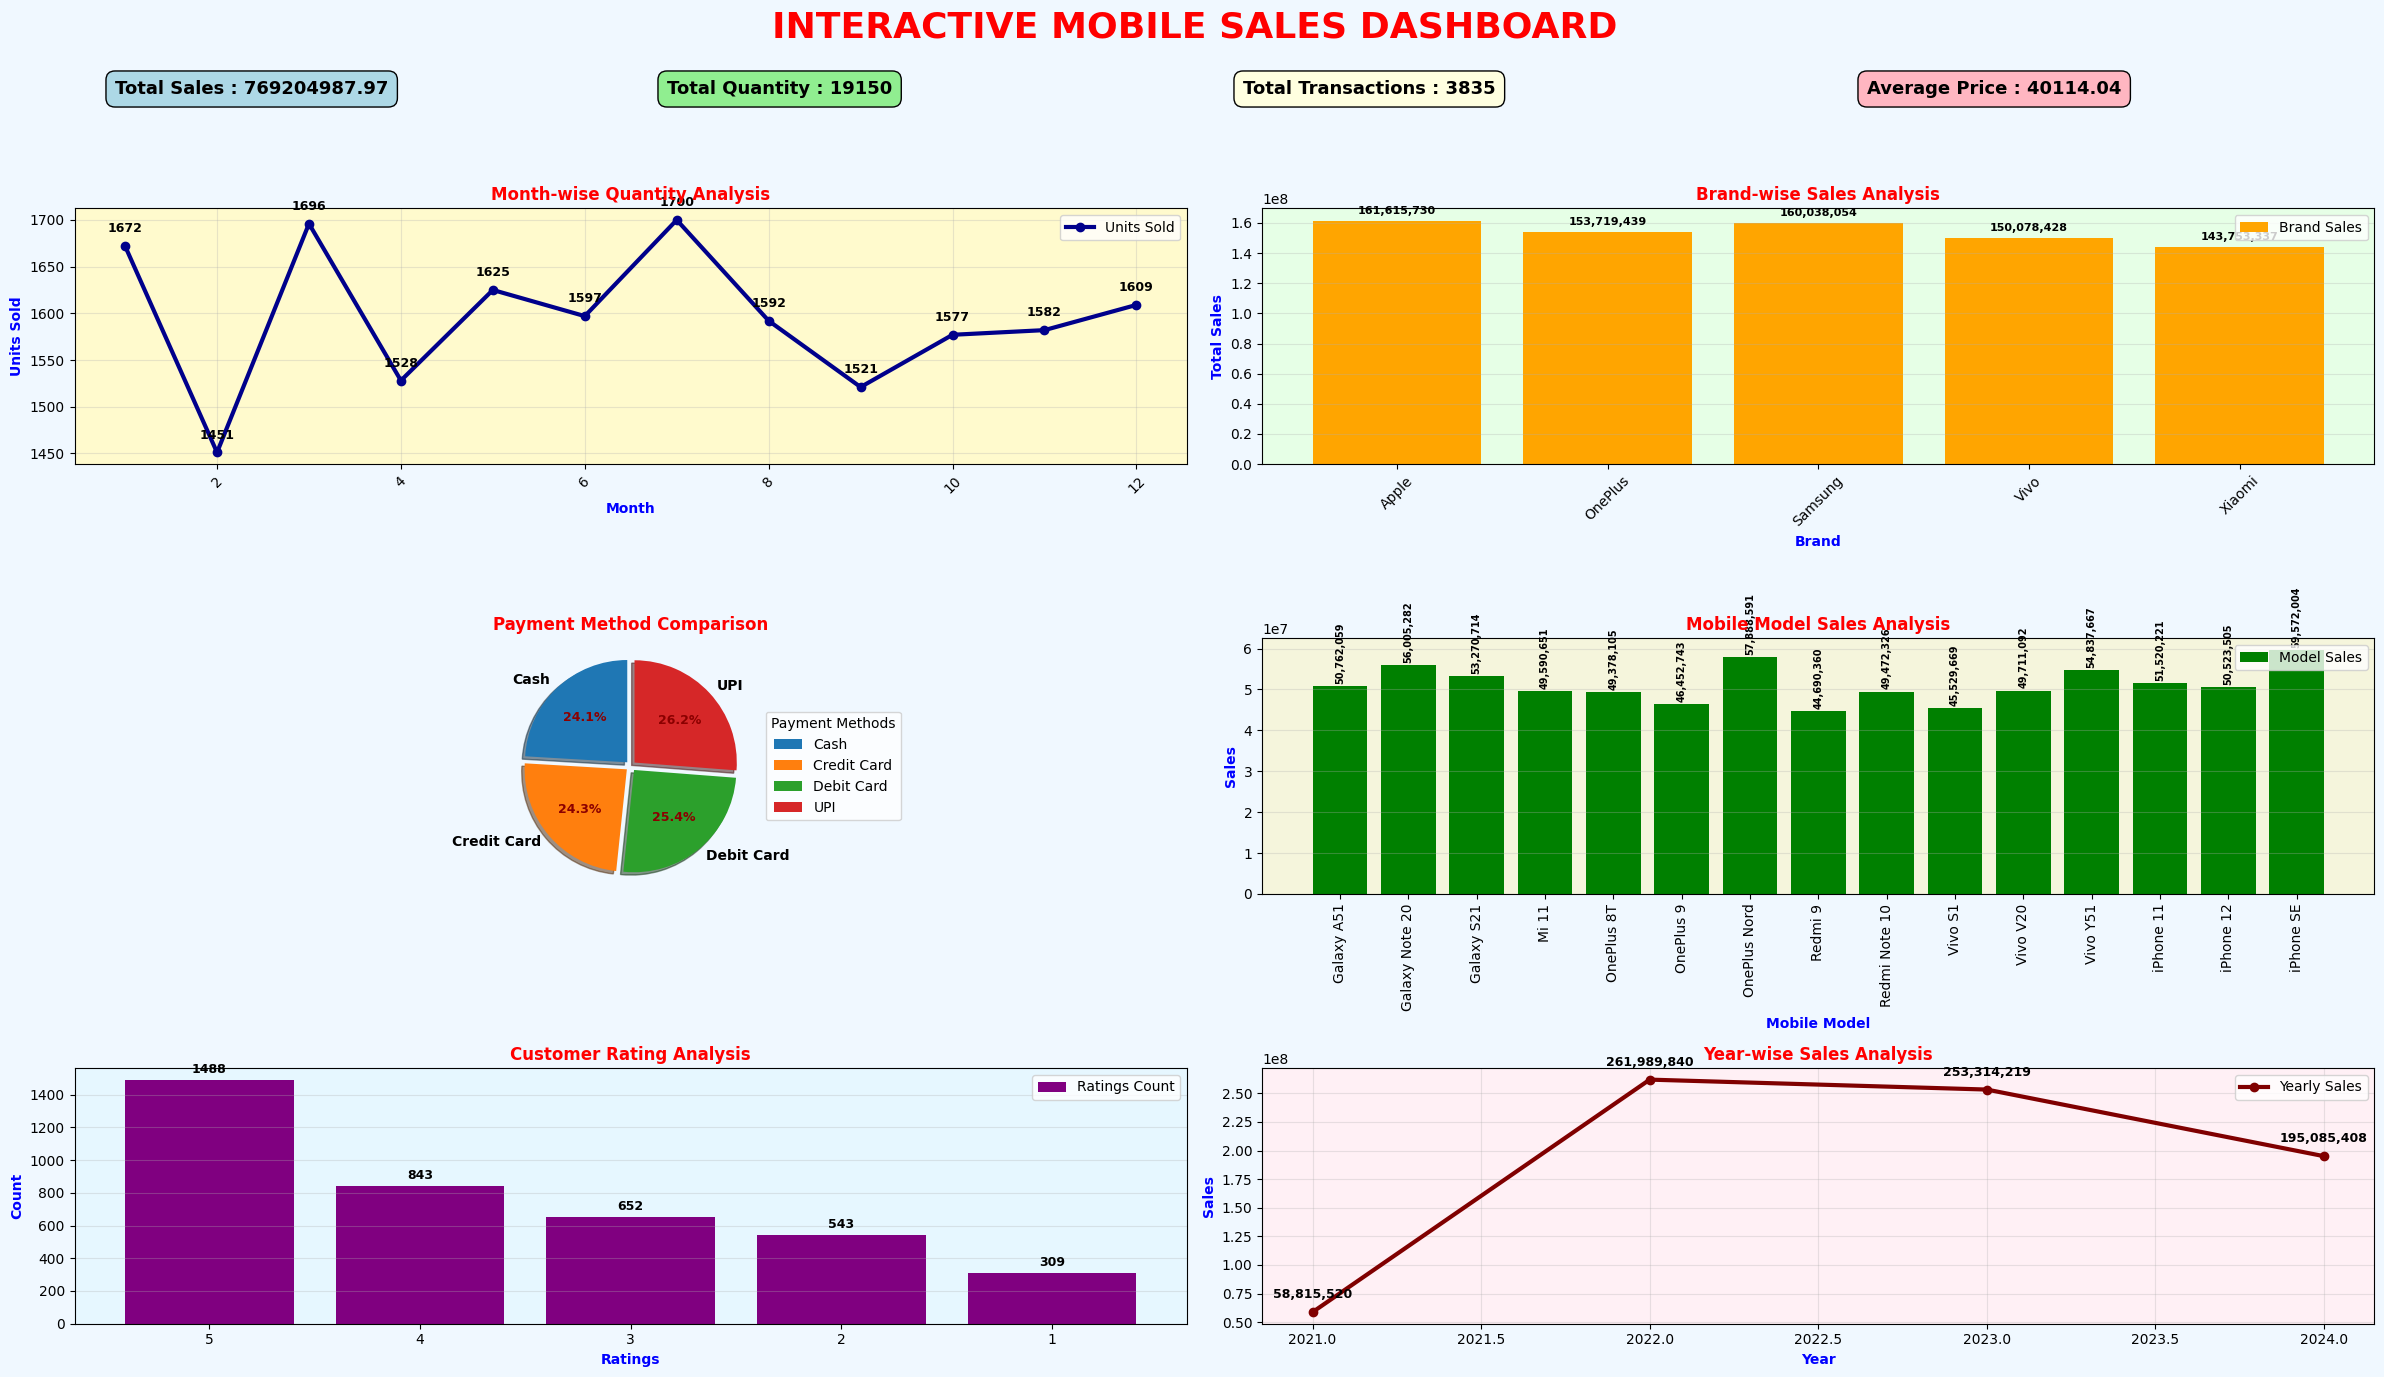

In [29]:
# =========================================================
# ADVANCED INTERACTIVE MOBILE SALES DASHBOARD
# WITH MULTIPLE FILTERS & IMPROVED PIE CHART
# =========================================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Load Dataset
# ---------------------------------------------------------

df = pd.read_excel('Mobile Sales Data.xlsx')

# ---------------------------------------------------------
# Create Total Sales Column
# ---------------------------------------------------------

df['Total Sales'] = df['Units Sold'] * df['Price Per Unit']

# =========================================================
# FILTER SECTION
# =========================================================

# ---------------------------------------------------------
# Brand Filter
# ---------------------------------------------------------

print("\nAvailable Brands :")
print(df['Brand'].unique())

brand_input = input("\nEnter Brand Name (or type ALL) : ")

# ---------------------------------------------------------
# Payment Method Filter
# ---------------------------------------------------------

print("\nAvailable Payment Methods :")
print(df['Payment Method'].unique())

payment_input = input("\nEnter Payment Method (or type ALL) : ")

# ---------------------------------------------------------
# Mobile Model Filter
# ---------------------------------------------------------

print("\nAvailable Mobile Models :")
print(df['Mobile Model'].unique())

model_input = input("\nEnter Mobile Model (or type ALL) : ")

# =========================================================
# APPLY FILTERS
# =========================================================

filtered_df = df.copy()

# Brand Filter
if brand_input.upper() != 'ALL':
    filtered_df = filtered_df[
        filtered_df['Brand'].str.lower() == brand_input.lower()
    ]

# Payment Method Filter
if payment_input.upper() != 'ALL':
    filtered_df = filtered_df[
        filtered_df['Payment Method'].str.lower() == payment_input.lower()
    ]

# Mobile Model Filter
if model_input.upper() != 'ALL':
    filtered_df = filtered_df[
        filtered_df['Mobile Model'].str.lower() == model_input.lower()
    ]

# =========================================================
# KPI CALCULATIONS
# =========================================================

total_sales = filtered_df['Total Sales'].sum()
total_quantity = filtered_df['Units Sold'].sum()
total_transactions = filtered_df['Transaction ID'].nunique()
avg_price = filtered_df['Price Per Unit'].mean()

# =========================================================
# FIGURE
# =========================================================

fig = plt.figure(figsize=(24,14))

fig.patch.set_facecolor('#f0f8ff')

# ---------------------------------------------------------
# Dashboard Title
# ---------------------------------------------------------

fig.suptitle(
    'INTERACTIVE MOBILE SALES DASHBOARD',
    fontsize=26,
    fontweight='bold',
    color='red'
)

# =========================================================
# KPI CARDS
# =========================================================

plt.figtext(
    0.05, 0.92,
    f'Total Sales : {round(total_sales,2)}',
    fontsize=13,
    fontweight='bold',
    bbox=dict(facecolor='lightblue',
              edgecolor='black',
              boxstyle='round,pad=0.5')
)

plt.figtext(
    0.28, 0.92,
    f'Total Quantity : {total_quantity}',
    fontsize=13,
    fontweight='bold',
    bbox=dict(facecolor='lightgreen',
              edgecolor='black',
              boxstyle='round,pad=0.5')
)

plt.figtext(
    0.52, 0.92,
    f'Total Transactions : {total_transactions}',
    fontsize=13,
    fontweight='bold',
    bbox=dict(facecolor='lightyellow',
              edgecolor='black',
              boxstyle='round,pad=0.5')
)

plt.figtext(
    0.78, 0.92,
    f'Average Price : {round(avg_price,2)}',
    fontsize=13,
    fontweight='bold',
    bbox=dict(facecolor='lightpink',
              edgecolor='black',
              boxstyle='round,pad=0.5')
)

# =========================================================
# 1. MONTH-WISE QUANTITY ANALYSIS
# =========================================================

ax1 = plt.subplot(3,2,1)

month_quantity = filtered_df.groupby('Month')['Units Sold'].sum()

ax1.plot(
    month_quantity.index,
    month_quantity.values,
    marker='o',
    linewidth=3,
    color='darkblue',
    label='Units Sold'
)

for x, y in zip(month_quantity.index, month_quantity.values):
    ax1.annotate(
        str(y),
        (x, y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

ax1.set_title(
    'Month-wise Quantity Analysis',
    color='red',
    fontweight='bold'
)

ax1.set_xlabel(
    'Month',
    color='blue',
    fontweight='bold'
)

ax1.set_ylabel(
    'Units Sold',
    color='blue',
    fontweight='bold'
)

ax1.tick_params(axis='x', colors='black', rotation=45)
ax1.tick_params(axis='y', colors='black')

ax1.legend()

ax1.grid(alpha=0.3)

ax1.set_facecolor('#fffacd')

# =========================================================
# 2. BRAND-WISE SALES ANALYSIS
# =========================================================

ax2 = plt.subplot(3,2,2)

brand_sales = filtered_df.groupby('Brand')['Total Sales'].sum()

bars = ax2.bar(
    brand_sales.index,
    brand_sales.values,
    color='orange',
    label='Brand Sales'
)

for bar in bars:
    height = bar.get_height()
    ax2.annotate(
        f'{height:,.0f}',
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext=(0,5),
        textcoords='offset points',
        ha='center',
        fontsize=8,
        fontweight='bold'
    )

ax2.set_title(
    'Brand-wise Sales Analysis',
    color='red',
    fontweight='bold'
)

ax2.set_xlabel(
    'Brand',
    color='blue',
    fontweight='bold'
)

ax2.set_ylabel(
    'Total Sales',
    color='blue',
    fontweight='bold'
)

ax2.tick_params(axis='x', colors='black', rotation=45)
ax2.tick_params(axis='y', colors='black')

ax2.legend()

ax2.grid(axis='y', alpha=0.3)

ax2.set_facecolor('#e6ffe6')

# =========================================================
# 3. PAYMENT METHOD COMPARISON
# =========================================================

ax3 = plt.subplot(3,2,3)

payment_sales = filtered_df.groupby('Payment Method')['Total Sales'].sum()

explode_values = [0.05] * len(payment_sales)

wedges, texts, autotexts = ax3.pie(
    payment_sales.values,
    labels=payment_sales.index,
    autopct='%1.1f%%',
    explode=explode_values,
    shadow=True,
    startangle=90
)

# Improve Pie Chart Text
for text in texts:
    text.set_fontsize(10)
    text.set_fontweight('bold')
    text.set_color('black')

for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')
    autotext.set_color('darkred')

ax3.set_title(
    'Payment Method Comparison',
    color='red',
    fontweight='bold'
)

# Custom Legend
ax3.legend(
    wedges,
    payment_sales.index,
    title='Payment Methods',
    loc='center left',
    bbox_to_anchor=(1,0.5)
)

ax3.set_facecolor('#ffe6f2')

# =========================================================
# 4. MOBILE MODEL SALES ANALYSIS
# =========================================================

ax4 = plt.subplot(3,2,4)

model_sales = filtered_df.groupby('Mobile Model')['Total Sales'].sum()

bars2 = ax4.bar(
    model_sales.index,
    model_sales.values,
    color='green',
    label='Model Sales'
)

for bar in bars2:
    height = bar.get_height()
    ax4.annotate(
        f'{height:,.0f}',
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext=(0,3),
        textcoords='offset points',
        ha='center',
        fontsize=7,
        rotation=90,
        fontweight='bold'
    )

ax4.set_title(
    'Mobile Model Sales Analysis',
    color='red',
    fontweight='bold'
)

ax4.set_xlabel(
    'Mobile Model',
    color='blue',
    fontweight='bold'
)

ax4.set_ylabel(
    'Sales',
    color='blue',
    fontweight='bold'
)

ax4.tick_params(axis='x', colors='black', rotation=90)
ax4.tick_params(axis='y', colors='black')

ax4.legend()

ax4.grid(axis='y', alpha=0.3)

ax4.set_facecolor('#f5f5dc')

# =========================================================
# 5. CUSTOMER RATING ANALYSIS
# =========================================================

ax5 = plt.subplot(3,2,5)

ratings = filtered_df['Customer Ratings'].value_counts()

bars3 = ax5.bar(
    ratings.index.astype(str),
    ratings.values,
    color='purple',
    label='Ratings Count'
)

for bar in bars3:
    height = bar.get_height()
    ax5.annotate(
        str(height),
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext=(0,5),
        textcoords='offset points',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

ax5.set_title(
    'Customer Rating Analysis',
    color='red',
    fontweight='bold'
)

ax5.set_xlabel(
    'Ratings',
    color='blue',
    fontweight='bold'
)

ax5.set_ylabel(
    'Count',
    color='blue',
    fontweight='bold'
)

ax5.tick_params(axis='x', colors='black')
ax5.tick_params(axis='y', colors='black')

ax5.legend()

ax5.grid(axis='y', alpha=0.3)

ax5.set_facecolor('#e6f7ff')

# =========================================================
# 6. YEAR-WISE SALES ANALYSIS
# =========================================================

ax6 = plt.subplot(3,2,6)

year_sales = filtered_df.groupby('Year')['Total Sales'].sum()

ax6.plot(
    year_sales.index,
    year_sales.values,
    marker='o',
    linewidth=3,
    color='maroon',
    label='Yearly Sales'
)

for x, y in zip(year_sales.index, year_sales.values):
    ax6.annotate(
        f'{y:,.0f}',
        (x, y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

ax6.set_title(
    'Year-wise Sales Analysis',
    color='red',
    fontweight='bold'
)

ax6.set_xlabel(
    'Year',
    color='blue',
    fontweight='bold'
)

ax6.set_ylabel(
    'Sales',
    color='blue',
    fontweight='bold'
)

ax6.tick_params(axis='x', colors='black')
ax6.tick_params(axis='y', colors='black')

ax6.legend()

ax6.grid(alpha=0.3)

ax6.set_facecolor('#fff0f5')

# ---------------------------------------------------------
# Layout
# ---------------------------------------------------------

plt.tight_layout(rect=[0,0,1,0.90])

# ---------------------------------------------------------
# Show Dashboard
# ---------------------------------------------------------

plt.show()